# φ⁴ Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{raw} = H_0 + \frac{g}{24 \cdot r \cdot 8\pi}\,\delta H_4$$

$$H_\text{LO} = H_0 + \frac{1}{4} m_2^2 \,\delta H_2 + \frac{g+\lambda_2}{24 \cdot r \cdot 8\pi}\,\delta H_4$$

and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941


In [1]:
import math
import bisect
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sp_linalg
from scipy.special import factorial
from scipy.sparse import csr_matrix, identity
import matplotlib.pyplot as plt
from collections import Counter
import time
import csv
import matplotlib.ticker as ticker
import seaborn as sns

%matplotlib inline

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as lists `[n₀, n₁₊, n₁₋, n₂₊, n₂₋, …]` where the helper `ix(l,σ)` gives the list index.


In [2]:
omega_list = []   # omega_list[l] = sqrt(l²/r² + m²)

def omega(l, m, r):
    """State Frequency"""
    return math.sqrt(float(l)*float(l)/(r*r) + m*m)

def gen_omega_list(lmax, m, r):
    global omega_list
    omega_list = [omega(l, m, r) for l in range(lmax + 1)]

def ix(l, sigma):
    """State-list index for mode (l, sigma)."""
    if l == 0: return 0
    return 2*l - 1 if sigma >= 0 else 2*l

def the_l(i):
    """Mode number from state-list index."""
    if i == 0: return 0
    return int((i+1)/2) if i % 2 != 0 else int(i/2)

def the_sigma(i):
    if i == 0: return 0
    return 1 if i % 2 != 0 else -1


## 2. Basis generation

`gen_basis` recursively builds all occupation-number states with energy ≤ `e_max`.
We then filter to the **zero-total-momentum** sector (`l_total == 0`) and optionally
to the **even-parity** sector (even total particle number).


In [3]:
def gen_coins(n_max):
    global coins
    #Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    #If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        coins[i] = sorted(coins[i], key=len) #Not sure this helps?
    return coins

def coin_dict():
    #Turns above into a counting dictionary
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(val) for val in coins[key]]
        
def coin_energies(l,m,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, m, r), change)) for change in coins[l]]
    
            

In [4]:
gen_coins(7)
for i in range(1,8):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

lmax = 1
Coins = [1], Energy = 1.4142135623730951
lmax = 2
Coins = [2], Energy = 2.23606797749979
Coins = [1, 1], Energy = 2.8284271247461903
lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1], Energy = 5.656854249492381
lmax = 5
Coins = [5], Energy = 5.0990195135927845
Coins = [3, 2], Energy = 5.39834563766817
Coins = [4, 1], Energy = 5.5373191879907555
Coins = [2, 2, 1], Energy = 5.8863495173726745
Coins = [3, 1, 1], Energy = 5.99070478491457
Coins = [2, 1, 1, 1], Energy = 6.4787086646190755
Coins = [1, 1, 1, 1, 1], Energy = 7.0710678118654755
lmax = 6
Coins = [6], Energy = 6.082762530298219
Coins = [3, 3], Energy = 6.324555320336759
Coins = [4, 2], Energy = 6.35917360311745
Coins = [5, 1], Energy = 

In [5]:
def gen_basis(lmax, e_max, m, r):
    result = []
    #l=0:
    result += [{0: i} for i in range(0, int(math.floor(e_max/m)) + 1)]    
    #l>0:
    for l in range(1,lmax+1):
        gen_coins(l) #All ways of making up to lmax with smaller numbers
        coin_dict()
        coinEnergies = coin_energies(l,m,r)

        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                #Build a temporary energy for the state
                e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                if e_temp > 0: #Fill up l=0 state up to e_max.
                    cicjDict = {-jjj:cjj for jjj,cjj in cj.items()} | ci 
                    result += [cicjDict]
                    result += [{0: i} | cicjDict for i in range(1, int(math.floor(e_temp/m)) + 1)]
                
    return result

In [7]:
def effective_lmax(lmax, e_max, m, r):
    if m**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - m**2))))))
    return 0

## 3. Timing Between Old Method and New Method

E_max: 6 | Time: 0.002457 seconds
E_max: 7 | Time: 0.000248 seconds
E_max: 8 | Time: 0.000252 seconds
E_max: 9 | Time: 0.000239 seconds
E_max: 10 | Time: 0.000366 seconds
E_max: 11 | Time: 0.000688 seconds
E_max: 12 | Time: 0.000948 seconds
E_max: 13 | Time: 0.006333 seconds
E_max: 14 | Time: 0.002451 seconds
E_max: 15 | Time: 0.003460 seconds
E_max: 16 | Time: 0.005399 seconds
E_max: 17 | Time: 0.008232 seconds
E_max: 18 | Time: 0.011919 seconds
E_max: 19 | Time: 0.017801 seconds


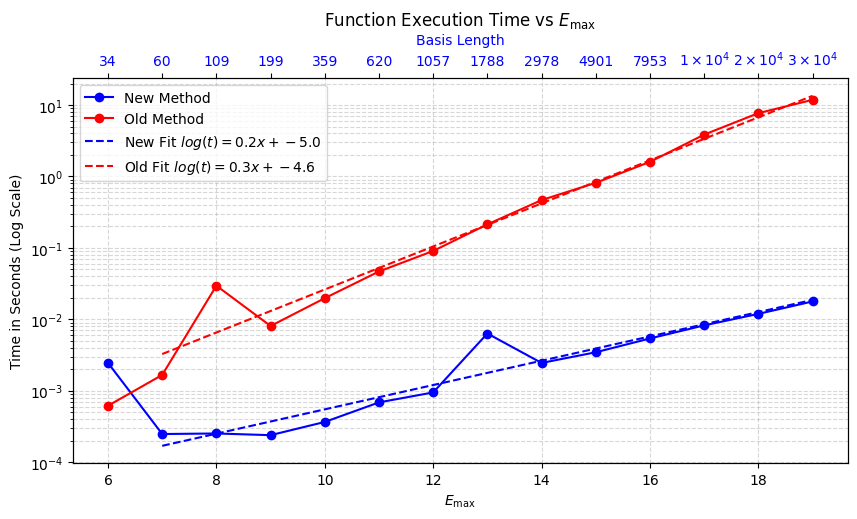

In [8]:
m = 1; r = 10/(2*math.pi)
execution_times = []; len_basis = []

emax_list = range(6,20)

for emax in emax_list:
    start_time = time.perf_counter()
    lmaxeff = effective_lmax(emax,emax,m,r)
    basis = gen_basis(lmaxeff,emax,m,r)  # Execute the function
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    execution_times.append(duration)
    len_basis.append(len(basis))
    
    del coins #For fairness, reset the coins dictionary each time.
    
    print(f"E_max: {emax} | Time: {duration:.6f} seconds")

csv_filename = "benchmark_results.csv"
execution_times_old = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    
    for row in reader:
        execution_times_old.append(float(row[1])) # Convert time back to float


# 4. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='New Method')
ax1.plot(emax_list, execution_times_old, marker ='o', linestyle='-', color='r', label='Old Method')


coef_new = (np.polyfit(emax_list[1:], np.log10(execution_times)[1:], 1))
coef_old = (np.polyfit(emax_list[1:], np.log10(execution_times_old)[1:], 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', label=f'New Fit $log(t)={coef_new[0]:.1f}x+{coef_new[1]:.1f}$')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', label=f'Old Fit $log(t)={coef_old[0]:.1f}x+{coef_old[1]:.1f}$')
ax1.legend()


ax2 = ax1.twiny() 
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(emax_list) 

formatted_top_labels = []
for x in len_basis:
    if x>10000:
        base, exponent = f"{x:.0e}".split("e")
        # Clean up the sign on the exponent (e.g., +06 becomes 6)
        exponent = int(exponent) 
        # Wrap in LaTeX math style for true superscripts
        formatted_top_labels.append(f"${base} \\times 10^{{{exponent}}}$")
    else:
        formatted_top_labels.append(x)
    
ax2.set_xticklabels(formatted_top_labels) 
ax2.set_xlabel('Basis Length', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')


plt.title(r'Function Execution Time vs $E_\text{max}$')
plt.show()


## 3. State Occupation Plot

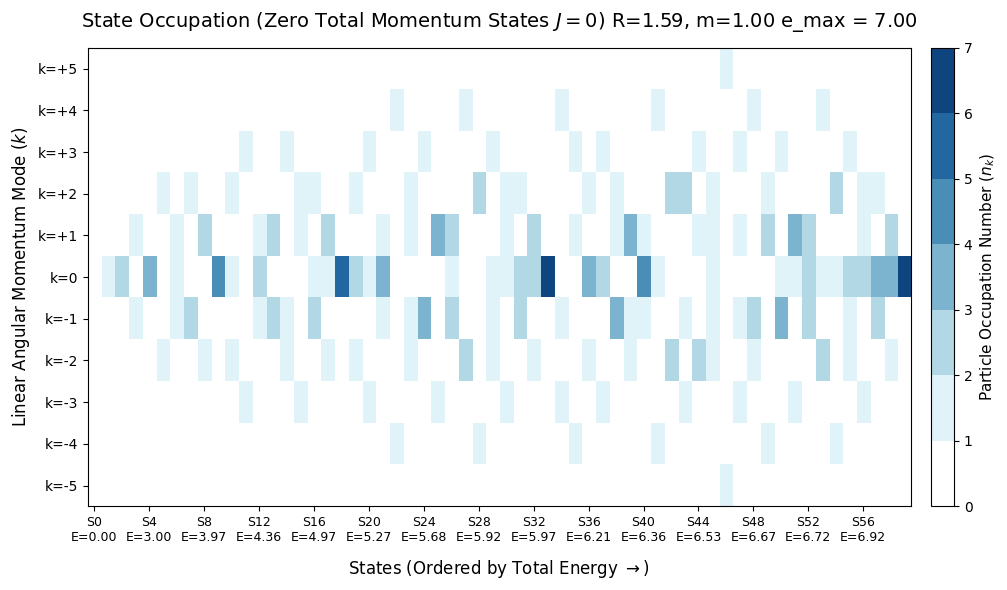

In [9]:
m = 1; r = 10/(2*math.pi); e_max=7; lmaxeff = effective_lmax(e_max,e_max,m,r)
basis = gen_basis(lmaxeff,e_max,m,r)

from matplotlib.colors import ListedColormap
# -- Mode Range and J=0 Basis for Plot ---

lrange = lmaxeff
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))


# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    state_energies.append(sum([nl*omega(l, m, r) for l, nl in state.items()]))
    
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Linear Grid Matrix ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes]
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]

ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
ax.set_xticklabels(_state_labels, fontsize=9)
ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={m:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

## 4. Raising and lowering operators, given two states of ordered energy.

In [10]:
def lower4(stA, stB): #Lowers state A to state B.
    diff = stA.copy() #Start with state A
    for j in stB.keys():
        if j in stA.keys():
            diff[j] = (stA[j] - stB[j])
            if diff[j]<0:
                return 0 
        elif stB[j]>0:
            return 0
    if len(diff)>0:
        hammDist = sum(diff.values())
        if hammDist!=4: #Hamming Distance Must Be 4.
            return 0
    norm = 1; factor = 24
    for l in diff.keys():
        factor *= 1/(factorial(diff[l]) * math.sqrt(omega(abs(l),m,r)**diff[l]))
        i=0
        while diff[l]>0:
            norm*=math.sqrt(stA[l]-i)
            i+=1
            diff[l]-=1
    return norm*factor

In [161]:
def raise1low3(stA, stB):#Currently set up so energy of state A > energy of state B.
    diff = stA.copy() #Start with state A
    for j in stB.keys():
        if j in stA.keys():
            diff[j] = (stA[j] - stB[j])
        elif stB[j]>0:
            diff[j]=-stB[j]
    if len(diff)>0:
        hammDist = sum(map(abs,diff.values()))
    
    
    if hammDist==4:
        if sum(diff.values())==0 or sum(diff.values())==-4: #Checks if you're using the incorrect function
            return 0
        norm = 1; factor = 4 * 6 #No additional factor of 2 as complex conjugate does transpose of matrix.
        for l in diff.keys():
            factor *= 1/factorial(abs(diff[l])) #Fixes symmetry factor.
            i=0
            while diff[l]!=0:
                factor *= 1/math.sqrt(omega(abs(l),m,r)) #Energy Scaling for Operator.
                if diff[l]>0:
                    #For destruction, find the norm then reduce occupation by 1.
                    norm*=math.sqrt(stA[l]-i)
                    i+=1
                    diff[l]-=1
                else:
                    if l in stA.keys():
                        #For creation, increase occupation by 1 then find norm.
                        norm*=math.sqrt(stA[l]+i+1)
                    else:
                        norm*=math.sqrt(i+1)
                    i+=1
                    diff[l]+=1
        return norm*factor
    

    elif hammDist==2:
        print(f'stA={stA}, stB={stB}')
        print(diff)
        tempA = stA.copy(); tempDiff = diff.copy() 
        norm = 1; factor = 4 * 6 #No additional factor of 2 as complex conjugate does transpose of matrix.
        for l in diff.keys():
            factor *= 1/factorial(abs(diff[l])) #Fixes symmetry factor.
            i=0
            while diff[l]>0:
                factor *= 1/math.sqrt(omega(abs(l),m,r)) #Energy Scaling for Operator.
                norm*=math.sqrt(stA[l]-i)
                i+=1
                diff[l]-=1
                tempA[l]-=1
                
        #Now if you've taken too much from state A, you won't be able to finish the operation...
        
        print(f'norm={norm},temp={tempA}')
        normSum = 0; factorSum=0
        for tl in tempA.keys():
            print(tempA)
            if tempA[tl]>0:
                factorSum += 1/omega(abs(tl),m,r) #Energy Scaling for Operator, squared.
                if tl in tempDiff.keys():
                    print('hello')
                    factorSum*=1/(abs(tempDiff[tl])+1)
                if tl!=0 and -tl in tempDiff.keys():
                    print(f'diff = {tempDiff}, tl={tl}')
                    factorSum*=1/(abs(tempDiff[tl])+1)
                    
                normSum+=np.sqrt(tempA[tl])*np.sqrt(tempA[tl]) #Essentially square the remaining quantity
        print(factorSum)
        print(normSum)
        return norm*normSum*factor*factorSum
    
    else: return 0


In [162]:
stA={0:3}; stB={0:1}

print(raise1low3(stA, stB))

stA={0: 3}, stB={0: 1}
{0: 2}
norm=2.4494897427831783,temp={0: 1}
{0: 1}
hello
0.3333333333333333
1.0
9.797958971132712


In [116]:
def raise2low2(stA, stB):#Currently set up so energy of state A > energy of state B.
    diff = stA.copy() #Start with state A
    for j in stB.keys():
        if j in stA.keys():
            diff[j] = (stA[j] - stB[j])
        elif stB[j]>0:
            diff[j]=-stB[j]
    if len(diff)>0:
        hammDist = sum(map(abs,diff.values()))
    
    print(diff)
    if hammDist==4:
        if sum(diff.values())!=0: #Checks if you're using the incorrect function.
            return 0
        norm = 1; factor = 4 * 6 * 2 #Additional factor of 2 is for complex conjugate.
        for l in diff.keys():
            factor *= 1/factorial(abs(diff[l])) #Fixes symmetry factor.
            
            i=0
            while diff[l]!=0:
                factor *= 1/math.sqrt(omega(abs(l),m,r)) #Energy Scaling for Operator.
                if diff[l]>0:
                    norm*=math.sqrt(stA[l]-i)
                    i+=1
                    diff[l]-=1
                else:
                    if l in stA.keys():
                        norm*=math.sqrt(stA[l]+i+1)
                    else:
                        norm*=math.sqrt(i+1)
                    i+=1
                    diff[l]+=1
        norm=1
        return norm*factor
    
    else: return 0

In [102]:
stA={-2: 1, 2:1}; stB={-1:1,1:1}

print(raise2low2(stA, stB))

{-2: 1, 2: 1, -1: -1, 1: -1}
-2
0.7890988482436785
2
0.7890988482436785
-1
1.0867427533696263
1
1.0867427533696263
0.5272411676616651


In [103]:
stA={-2: 1, 2:1}; stB={-1:1,1:1}

print(raise2low2(stA, stB))

{-2: 1, 2: 1, -1: -1, 1: -1}
-2
0.7890988482436785
2
0.7890988482436785
-1
1.0867427533696263
1
1.0867427533696263
0.5272411676616651


## 5. Transition Matrix by Hamming Distance 

stA={0: 2}, stB={0: 0}
{0: 2}
norm=1.4142135623730951,temp={0: 0}
{0: 0}
0
0
stA={-1: 1, 1: 1}, stB={0: 0}
{-1: 1, 1: 1}
norm=1.0,temp={-1: 0, 1: 0}
{-1: 0, 1: 0}
{-1: 0, 1: 0}
0
0
stA={-2: 1, 2: 1}, stB={0: 0}
{-2: 1, 2: 1}
norm=1.0,temp={-2: 0, 2: 0}
{-2: 0, 2: 0}
{-2: 0, 2: 0}
0
0
stA={-3: 1, 3: 1}, stB={0: 0}
{-3: 1, 3: 1}
norm=1.0,temp={-3: 0, 3: 0}
{-3: 0, 3: 0}
{-3: 0, 3: 0}
0
0
stA={0: 3}, stB={0: 1}
{0: 2}
norm=2.4494897427831783,temp={0: 1}
{0: 1}
hello
0.3333333333333333
1.0
stA={0: 1, -1: 1, 1: 1}, stB={0: 1}
{0: 0, -1: 1, 1: 1}
norm=1.0,temp={0: 1, -1: 0, 1: 0}
{0: 1, -1: 0, 1: 0}
hello
{0: 1, -1: 0, 1: 0}
{0: 1, -1: 0, 1: 0}
1.0
1.0
stA={0: 1, -2: 1, 2: 1}, stB={0: 1}
{0: 0, -2: 1, 2: 1}
norm=1.0,temp={0: 1, -2: 0, 2: 0}
{0: 1, -2: 0, 2: 0}
hello
{0: 1, -2: 0, 2: 0}
{0: 1, -2: 0, 2: 0}
1.0
1.0
stA={0: 2}, stB={0: 0}
{0: 2}
norm=1.4142135623730951,temp={0: 0}
{0: 0}
0
0
{-1: 1, 1: 1, 0: -2}
{-2: 1, 2: 1, 0: -2}
stA={0: 4}, stB={0: 2}
{0: 2}
norm=3.4641016151377544,temp={0:

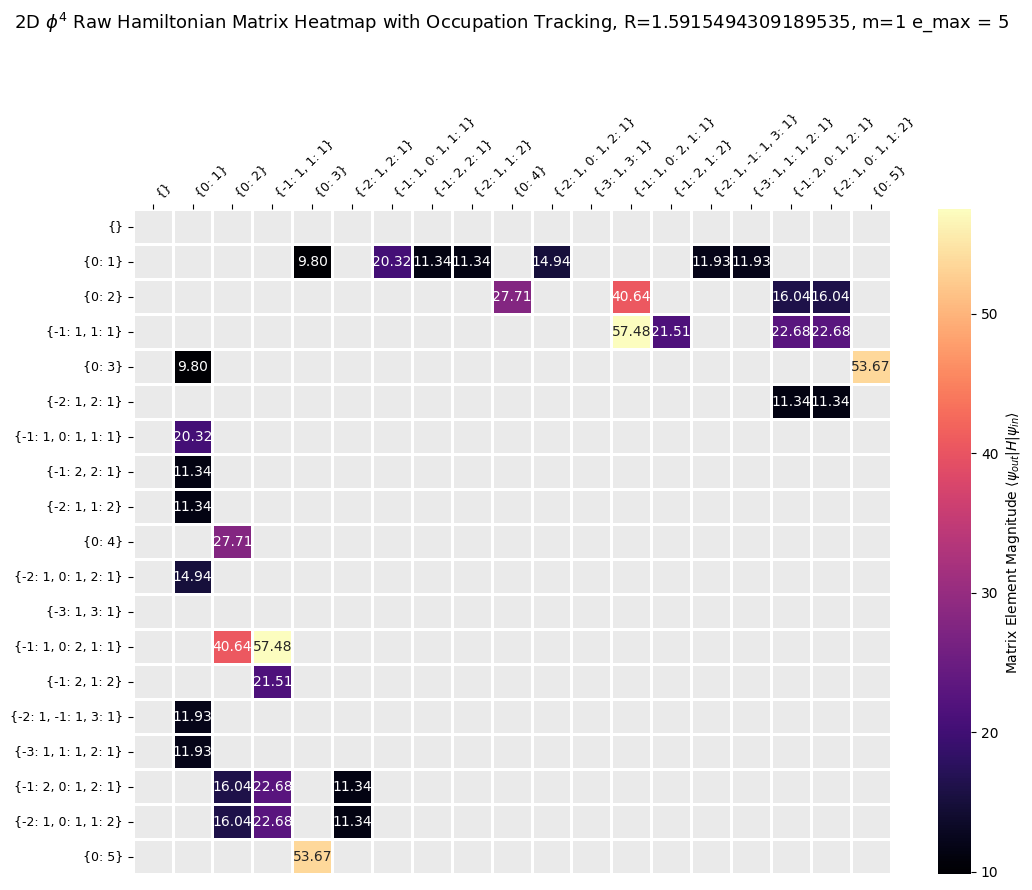

In [163]:
m = 1; r = 10/(2*math.pi); e_max=5; lmaxeff = effective_lmax(e_max,e_max,m,r)
basis = gen_basis(lmaxeff,e_max,m,r)

# -- Mode Range and J=0 Basis for Plot ---
lrange = lmaxeff 
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))

# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    state_energies.append(sum([nl*omega(l, m, r) for l, nl in state.items()]))
    
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Generate Raw Hamiltonian Matrix ---
H_total = np.zeros((len(sorted_states), len(sorted_states)))

#We can figure out which transitions between states are allowed by calculating the Hamming distance
for ii, si in enumerate(sorted_states):
    for jj, sj in enumerate(sorted_states):
        if ii == jj and ii>0:
            H_total[ii,jj]=0
            
        else:                
            diff = si.copy()
            for j in sj.keys():
                if j in si.keys():
                    diff[j] = abs(si[j] - sj[j])
                else:
                    diff[j] = sj[j]

            if len(diff)>0:
                hammDist = sum(diff.values())
                
                if hammDist==4:
                    #Firstly tries four lowering operators.
                    lower4Mag = lower4(si,sj) if ii>jj else lower4(sj,si)
                    if lower4Mag>0:
                        H_total[ii,jj]= lower4Mag
                        H_total[ii,jj]= 0
                    
                    #If that didn't work, tries three lowering operators and a single raising operator.
                    else: 
                        lower3raise1Mag = raise1low3(si,sj) if ii>jj else raise1low3(sj,si)
                        if lower3raise1Mag>0:
                            H_total[ii,jj]= lower3raise1Mag
                            
                        #Finally tries lowering twice and raising twice.
                        else:
                            lower2raise2Mag = raise2low2(si,sj) if ii>jj else raise2low2(sj,si)
                            if lower2raise2Mag>0:
                                #H_total[ii,jj]= lower2raise2Mag
                                H_total[ii,jj]= 0
                            
                if hammDist==2:
                    lower3raise1Mag = raise1low3(si,sj) if ii>jj else raise1low3(sj,si)
                    if lower3raise1Mag>0:
                        H_total[ii,jj]= lower3raise1Mag

# --- State labels ---
verbose_labels = []

for state in sorted_states:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}")


# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(11, 9))

zero_mask = (H_total == 0.0)
ax = sns.heatmap(
    H_total, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

'''#Adding 0.00 to the zero entries for clarity.
for y in range(H_sorted.toarray().shape[0]):
    for x in range(H_sorted.toarray().shape[1]):
        if zero_mask[y, x]:
            ax.text(
                x + 0.5, y + 0.5, '0.00',     # Centering coordinates inside the grid cell
                ha='center', va='center',    # Direct spatial centering properties
                color='gray',                # Uses a muted color so it doesn't distract from the real data
                fontsize=9,                  # Match or slightly shrink font size
                fontweight='light'
            )'''


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^4$ Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={m} e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


## 6. Diagonalization

For small matrices we use dense `eigvalsh`. For large ones we use a sparse shift-invert trick to find the `k` lowest eigenvalues without forming the dense matrix.

In [ ]:
def compute_eigenvalues(H, k):
    """Return the k lowest eigenvalues of sparse symmetric H."""
    n = H.shape[0]
    k = min(k, n)
    if k > n - 2:
        return sorted(np.linalg.eigvalsh(H.toarray()))[:k]
    # Shift by the matrix norm so eigs(..., which='LM') finds the most-negative eigenvalues of H
    norm = sp_linalg.norm(H)
    eigs = sp_linalg.eigs(H - norm*identity(n), k, which='LM')[0]
    return sorted((eigs.real + norm).tolist())


## 6. Quick example

Build `H_LO=H₀+(m^2/4)·H_2 +(g+\lambda_2/24)·H₄` and `H_raw = H₀ + (g/24)·H₄` for a single `E_max` and print the lowest eigenvalues.

In [ ]:
m, r, g = 1.0, 10/(2*math.pi), 4*math.pi
e_max = 5
l_uv=1000 #Wilsonian momentum cutoff far exceeding the energy scales we're modelling with H_eff.


lmaxeff = effective_lmax(e_max, e_max, m, r)
gen_omega_list(l_uv + 1, m, r)
basisShort = basis_l0(make_basis(lmaxeff, e_max, m, r))
basisLong = make_basis(lmaxeff, e_max, m, r)

print(basisLong)
print(len(basisLong))
print(basisShort)
print(len(basisShort))

[[0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 1], [0, 0, 1, 0, 0, 1, 0], [0, 0, 1, 0, 1, 0, 0], [0, 0, 1, 1, 0, 0, 0], [0, 0, 2, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 1], [0, 1, 0, 0, 0, 1, 0], [0, 1, 0, 0, 1, 0, 0], [0, 1, 0, 1, 0, 0, 0], [0, 1, 1, 0, 0, 0, 0], [0, 2, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 0, 0], [1, 0, 0, 1, 0, 0, 0], [1, 0, 1, 0, 0, 0, 0], [1, 0, 1, 0, 0, 0, 1], [1, 0, 1, 0, 0, 1, 0], [1, 0, 1, 0, 1, 0, 0], [1, 0, 1, 1, 0, 0, 0], [1, 0, 2, 0, 0, 0, 0], [1, 1, 0, 0, 0, 0, 0], [1, 1, 0, 0, 0, 0, 1], [1, 1, 0, 0, 0, 1, 0], [1, 1, 0, 0, 1, 0, 0], [1, 1, 0, 1, 0, 0, 0], [1, 1, 1, 0, 0, 0, 0], [1, 2, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 1], [2, 0, 0, 0, 0, 1, 0], [2, 0, 0, 0, 1, 0, 0], [2, 0, 0, 1, 0, 0, 0], [2, 0, 1, 0, 0, 0, 0], [2, 0, 1, 0, 1, 0, 0], [2, 0, 1, 

In [ ]:
m, r, g = 1.0, 10/(2*math.pi), 4*math.pi
e_max = 8
l_uv=1000 #Wilsonian momentum cutoff far exceeding the energy scales we're modelling with H_eff.


lmaxeff = effective_lmax(e_max, e_max, m, r)
gen_omega_list(l_uv + 1, m, r)
basis = basis_l0(make_basis(lmaxeff, e_max, m, r))


basis.sort()
print(f'e_max={e_max}, lmaxeff={lmaxeff}, basis size={len(basis)}')

H0   = h0(lmaxeff, e_max, m, r, basis)
H2   = delta_h2(lmaxeff, e_max, m, r, basis)
H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, basis)
H_raw = H0 + (g/24)*H4

H_LO = H0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*H2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*H4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)


eigs_LO  = compute_eigenvalues(H_LO,  10)
eigs_raw = compute_eigenvalues(H_raw, 10)

print('\nLowest 10 Leading Order eigenvalues:', [f'{e:.4f}' for e in eigs_LO])
print('Lowest 10 Raw eigenvalues:', [f'{e:.4f}' for e in eigs_raw])
print(f'LO gap E1-E0:         {eigs_LO[1]-eigs_LO[0]:.6f}')
print(f'Raw gap E1-E0:        {eigs_raw[1]-eigs_raw[0]:.6f}')


UnboundLocalError: cannot access local variable 'result' where it is not associated with a value

### Look at basis occupancy plots:

In [ ]:
#Re-orders the states from angular momenta as (0, +1, -1, +2, -2, ...) to (..., -2, -1, 0, +1, +2, ...)
def sort_modes(state, lmaxeff):
    sorted_state = []
    # Iterate linearly from -lmaxeff to +lmaxeff
    for new_index in range(-lmaxeff, lmaxeff + 1):            
        original_index=(ix(abs(new_index),np.sign(new_index)))
            
        if original_index<len(state):
            sorted_state.append(state[original_index])
        else: sorted_state.append(0)

    return sorted_state

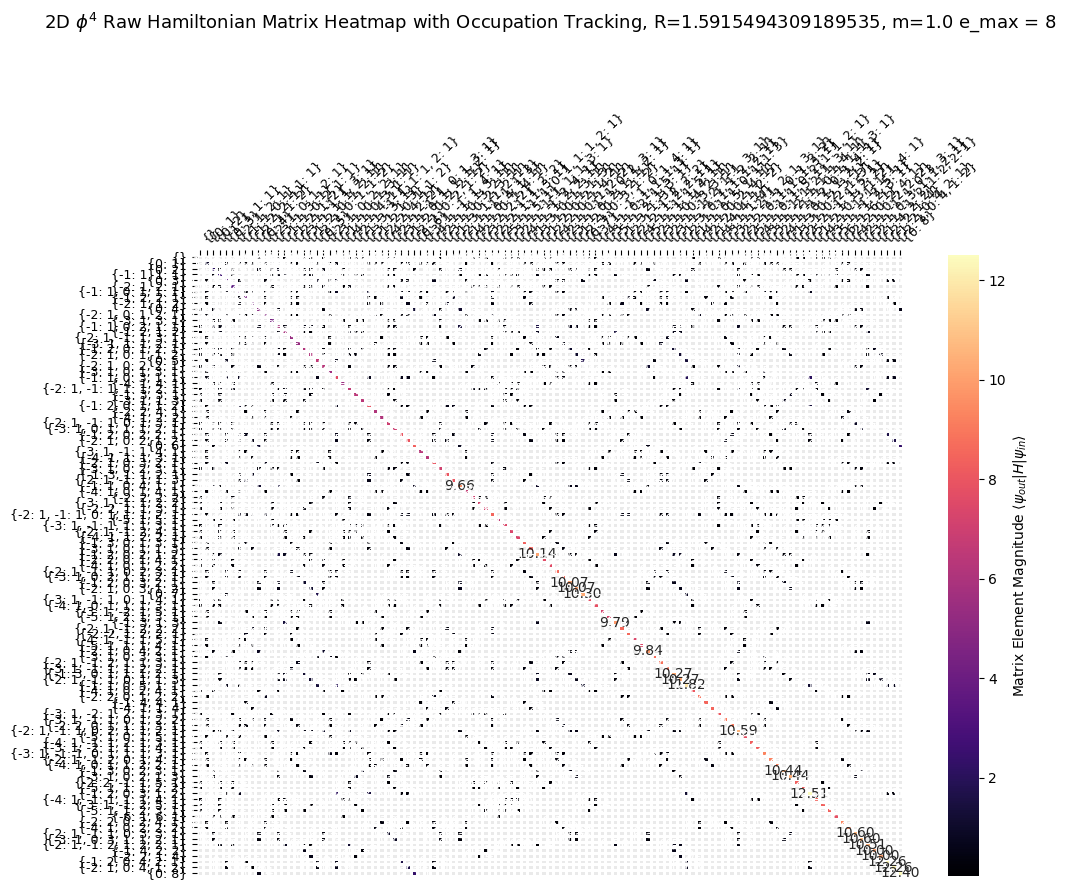

In [ ]:
import seaborn as sns

# -- Mode Range and J=0 Basis for Plot ---
lrange = lmaxeff 
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))

# --- Generate Raw Hamiltonian Matrix (H_0 + V) ---
H_total = h0(lmaxeff,e_max,m,r,_basis) + (g/24)*(1/r)*(1/(8*math.pi))*delta_h4(lmaxeff,e_max,m,r,_basis)


# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    sorted_states.append(sort_modes(state, lrange))
    state_energies.append(state_energy(state,m,r))
    
sorted_states=[x for x, _ in sorted(zip(sorted_states, state_energies), key=lambda pair: pair[1])]
sort_indices = np.argsort(state_energies)
H_sorted = H_total[sort_indices, :][:, sort_indices]

# --- State labels ---
verbose_labels = []

for state in sorted_states:
    occ_vector = {k:state[i] for i,k in enumerate(modes)}
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in occ_vector.items() if value !=0)+"}")


# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(11, 9))

zero_mask = (H_sorted.toarray() == 0.0)
ax = sns.heatmap(
    H_sorted.toarray(), 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

'''#Adding 0.00 to the zero entries for clarity.
for y in range(H_sorted.toarray().shape[0]):
    for x in range(H_sorted.toarray().shape[1]):
        if zero_mask[y, x]:
            ax.text(
                x + 0.5, y + 0.5, '0.00',     # Centering coordinates inside the grid cell
                ha='center', va='center',    # Direct spatial centering properties
                color='gray',                # Uses a muted color so it doesn't distract from the real data
                fontsize=9,                  # Match or slightly shrink font size
                fontweight='light'
            )'''


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^4$ Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={m} e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


## 7. Energy gap vs E_max at fixed volume

Scan `E_max` from 10 to 17 at fixed $r = 10/(2\pi)$, using the full zero-momentum basis.
We track the first energy gap $E_1 - E_0$ for both the raw theory (raw) and the Leading Order corrections (LO).

Raw error is expected to scale as $1/E_\text{Max}^2$ and LO as $1/E_\text{Max}^3$.


In [ ]:
m, r, g = 1.0, 10/(2*math.pi), 4*math.pi
n_eigens = 10
l_uv = 1000

scan_fixed = []
for e_max in range(8, 16): #Slightly larger emax gives better plots! Below seems like a bad fit.
    lmaxeff = effective_lmax(e_max, e_max, m, r)
    gen_omega_list(l_uv + 1, m, r)
    basis = basis_l0(make_basis(lmaxeff, e_max, m, r))
    basis.sort()

    H0   = h0(lmaxeff, e_max, m, r, basis)
    H2   = delta_h2(lmaxeff, e_max, m, r, basis)
    H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, basis)
    H_raw = H0 + (g/24)*H4
    H_LO = H0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*H2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*H4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)


    k = min(n_eigens, len(basis))
    eigs_raw = compute_eigenvalues(H_raw, k)
    eigs_LO = compute_eigenvalues(H_LO, k)
    scan_fixed.append({'e_max': e_max, 'eigs_raw': eigs_raw, 'eigs_LO': eigs_LO})
    print(f'e_max={e_max:2d}  lmaxeff={lmaxeff}  basis={len(basis)}')


e_max= 8  lmaxeff=6  basis=109
e_max= 9  lmaxeff=6  basis=199
e_max=10  lmaxeff=7  basis=359
e_max=11  lmaxeff=8  basis=620
e_max=12  lmaxeff=9  basis=1057
e_max=13  lmaxeff=10  basis=1788
e_max=14  lmaxeff=11  basis=2978
e_max=15  lmaxeff=11  basis=4901


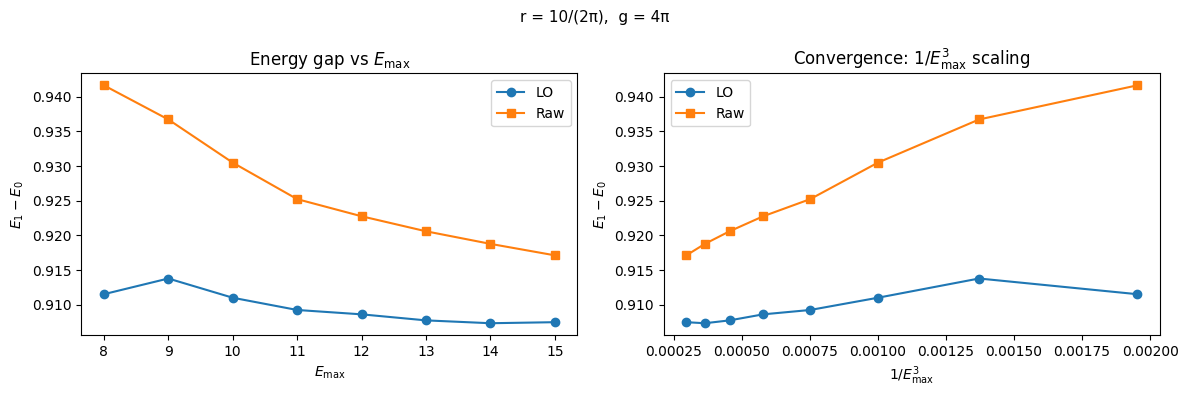

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

emax_vals = [row['e_max'] for row in scan_fixed]
gap_LO  = [row['eigs_LO'][1]  - row['eigs_LO'][0]  for row in scan_fixed if len(row['eigs_LO'])  > 1]
gap_raw = [row['eigs_raw'][1] - row['eigs_raw'][0] for row in scan_fixed if len(row['eigs_raw']) > 1]

axes[0].plot(emax_vals, gap_LO,  'o-', label='LO')
axes[0].plot(emax_vals, gap_raw, 's-', label='Raw')
axes[0].set_xlabel('$E_\\mathrm{max}$')
axes[0].set_ylabel('$E_1 - E_0$')
axes[0].set_title('Energy gap vs $E_\\mathrm{max}$')
axes[0].legend()

axes[1].plot([1/e**3 for e in emax_vals], gap_LO,  'o-', label='LO')
axes[1].plot([1/e**3 for e in emax_vals], gap_raw, 's-', label='Raw')
axes[1].set_xlabel('$1/E_\\mathrm{max}^3$')
axes[1].set_ylabel('$E_1 - E_0$')
axes[1].set_title('Convergence: $1/E_\\mathrm{max}^3$ scaling')
axes[1].legend()

fig.suptitle(f'r = 10/(2π),  g = 4π', fontsize=11)
fig.tight_layout()

#Agrees with https://arxiv.org/pdf/2110.08273 Figure 2.

## 8. Volume scan — even sector (main result)

Scan both $r$ (volume) and $E_\mathrm{max}$ using the **even-parity** zero-momentum basis.
For each volume we track $E_1^+ - E_0$ to see how quickly the gap converges with $E_\mathrm{max}$.

Note the zero eigenvalue of the even states is the same (numerically within errors here) as the zero eigenvalue of all states, i.e. E0. Note this is not the case for the odd states.

This is the main computation and may take a few minutes for the larger parameters.


In [ ]:
m, g = 1.0, 4*math.pi
n_eigens = 10
rN_values   = range(8, 12, 2)   #  →  r = rN/(2π)
emax_values = range(13, 17)      # e_max = 13 … 16

all_results = {}  # all_results[rN] = list of dicts per e_max

for rN in rN_values:
    r = rN / (2*math.pi)
    results = []
    for e_max in emax_values:
        lmax    = 100 * e_max
        lmaxeff = effective_lmax(lmax, e_max, m, r)
        gen_omega_list(lmaxeff + 1, m, r)

        #Even basis states:
        ebasis = basis_even(basis_l0(make_basis(lmaxeff, e_max, m, r)))
        ebasis.sort()
        en = len(ebasis)

        eH0   = h0(lmaxeff, e_max, m, r, ebasis)
        eH2   = delta_h2(lmaxeff, e_max, m, r, ebasis)
        eH4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, ebasis)

        eH_raw = eH0 + (g/24)*eH4
        eH_LO = eH0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*eH2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*eH4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)



        k = min(n_eigens, en) 
        eigs_raw = compute_eigenvalues(eH_raw,    k)
        eigs_LO  = compute_eigenvalues(eH_LO,     k)
        results.append({'e_max': e_max, 'lmaxeff': lmaxeff, 'n_basis': en,
                        'eigs_LO': eigs_LO, 'eigs_raw': eigs_raw}) 
        print(f'rN={rN:2d}  e_max={e_max:2d}  lmaxeff={lmaxeff:3d}  basis size={en}')
    all_results[rN] = results


rN= 8  e_max=13  lmaxeff=  8  basis size=373
rN= 8  e_max=14  lmaxeff=  8  basis size=575
rN= 8  e_max=15  lmaxeff=  9  basis size=906
rN= 8  e_max=16  lmaxeff= 10  basis size=1407
rN=10  e_max=13  lmaxeff= 10  basis size=880
rN=10  e_max=14  lmaxeff= 11  basis size=1478
rN=10  e_max=15  lmaxeff= 11  basis size=2457
rN=10  e_max=16  lmaxeff= 12  basis size=4016


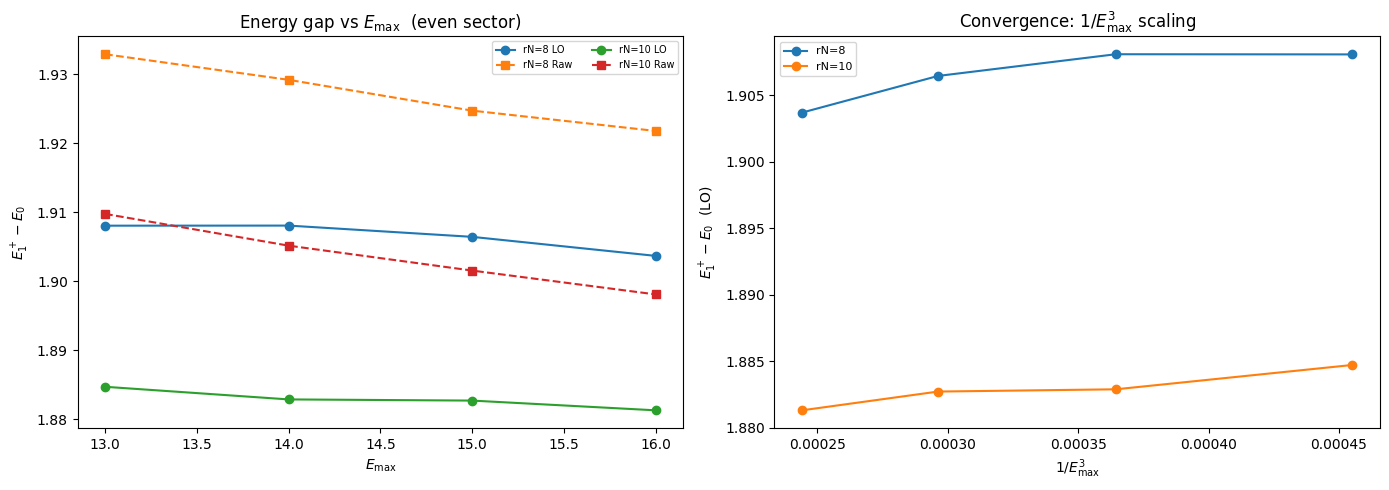

In [ ]:
# Energy gap E1+-E0 vs E_max for each volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rN, results in all_results.items():
    emax_vals = [r['e_max'] for r in results]
    gap_LO    = [r['eigs_LO'][1]  - r['eigs_LO'][0]  for r in results if len(r['eigs_LO'])  > 1]
    gap_raw   = [r['eigs_raw'][1] - r['eigs_raw'][0] for r in results if len(r['eigs_raw']) > 1]
    label = f'rN={rN}'
    axes[0].plot(emax_vals, gap_LO,  'o-',  label=f'{label} LO')
    axes[0].plot(emax_vals, gap_raw, 's--', label=f'{label} Raw')
    axes[1].plot([1/e**3 for e in emax_vals], gap_LO, 'o-', label=label)

axes[0].set_xlabel('$E_\\mathrm{max}$')
axes[0].set_ylabel('$E_1^+ - E_0$')
axes[0].set_title('Energy gap vs $E_\\mathrm{max}$  (even sector)')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('$1/E_\\mathrm{max}^3$')
axes[1].set_ylabel('$E_1^+ - E_0$  (LO)')
axes[1].set_title('Convergence: $1/E_\\mathrm{max}^3$ scaling')
axes[1].legend(fontsize=8)

fig.tight_layout()

#Agrees with figure 1 in https://arxiv.org/pdf/2507.15941 for rN=10

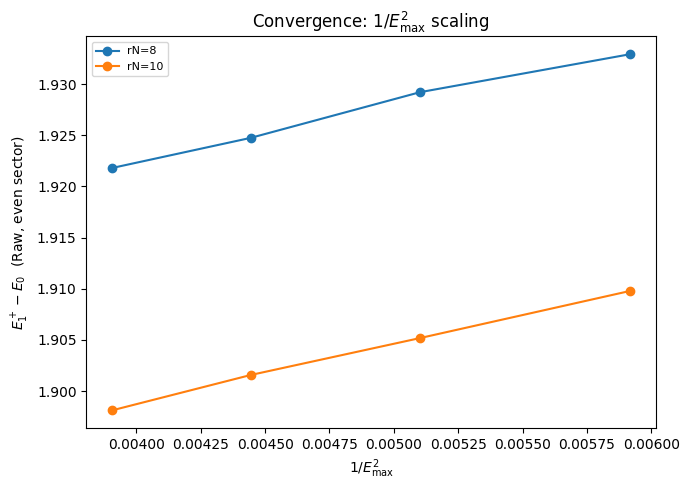

In [ ]:
# Same data on 1/E_max^2 axis for Raw gap
fig, ax = plt.subplots(figsize=(7, 5))

for rN, results in all_results.items():
    emax_vals = [r['e_max'] for r in results]
    gap_raw   = [r['eigs_raw'][1] - r['eigs_raw'][0] for r in results if len(r['eigs_raw']) > 1]
    ax.plot([1/e**2 for e in emax_vals], gap_raw, 'o-', label=f'rN={rN}')

ax.set_xlabel('$1/E_\\mathrm{max}^2$')
ax.set_ylabel('$E_1^+ - E_0$  (Raw, even sector)')
ax.set_title('Convergence: $1/E_\\mathrm{max}^2$ scaling')
ax.legend(fontsize=8)
fig.tight_layout()


## 9. Volume scan — odd sector 

Scan both $r$ (volume) and $E_\mathrm{max}$ using the **odd-parity** zero-momentum basis.
For each volume we track $E_1^- - E_0$ to see how quickly the gap converges with $E_\mathrm{max}$.

In [ ]:
m, g = 1.0, 4*math.pi
n_eigens = 10
rN_values   = range(8, 12, 2)   #  →  r = rN/(2π)
emax_values = range(13, 17)      # e_max = 13 … 16

all_results = {}  # all_results[rN] = list of dicts per e_max

for rN in rN_values:
    r = rN / (2*math.pi)
    results = []
    for e_max in emax_values:
        lmax    = 100 * e_max
        lmaxeff = effective_lmax(lmax, e_max, m, r)
        gen_omega_list(lmaxeff + 1, m, r)

        #Find the ground state energy:
        basis = basis_l0(make_basis(lmaxeff, e_max, m, r))
        basis.sort()
        n = len(basis)

        H0   = h0(lmaxeff, e_max, m, r, basis)
        H2   = delta_h2(lmaxeff, e_max, m, r, basis)
        H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, basis)

        H_raw = H0 + (g/24)*H4
        H_LO = H0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*H2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*H4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)

        E0_raw = compute_eigenvalues(H_raw,    1)
        E0_LO  = compute_eigenvalues(H_LO,     1)

        #Odd basis states:
        obasis = basis_odd(basis_l0(make_basis(lmaxeff, e_max, m, r)))
        obasis.sort()
        on = len(obasis)

        oH0   = h0(lmaxeff, e_max, m, r, obasis)
        oH2   = delta_h2(lmaxeff, e_max, m, r, obasis)
        oH4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, m, r, obasis)
        oH_raw = oH0 + (g/24)*oH4
        oH_LO = oH0 + (1/4)*mv2_sq(e_max, m, r, g, l_uv)*oH2 + 1/24*(g + lambda2(e_max, m, r, g, l_uv))*oH4 #See https://arxiv.org/pdf/2507.15941 Eq. (2.43)


        k = min(n_eigens, on) 
        eigs_raw = compute_eigenvalues(oH_raw,    k)
        eigs_LO  = compute_eigenvalues(oH_LO,     k)
        results.append({'e_max': e_max, 'lmaxeff': lmaxeff, 'n_basis': on,
                        'eigs_LO': eigs_LO, 'eigs_raw': eigs_raw, 'E0_LO': E0_LO, 'E0_raw': E0_raw})
        print(f'rN={rN:2d}  e_max={e_max:2d}  lmaxeff={lmaxeff:3d}  basis size={on}')
    all_results[rN] = results


rN= 8  e_max=13  lmaxeff=  8  basis size=372
rN= 8  e_max=14  lmaxeff=  8  basis size=593
rN= 8  e_max=15  lmaxeff=  9  basis size=903
rN= 8  e_max=16  lmaxeff= 10  basis size=1374
rN=10  e_max=13  lmaxeff= 10  basis size=908
rN=10  e_max=14  lmaxeff= 11  basis size=1500


KeyboardInterrupt: 

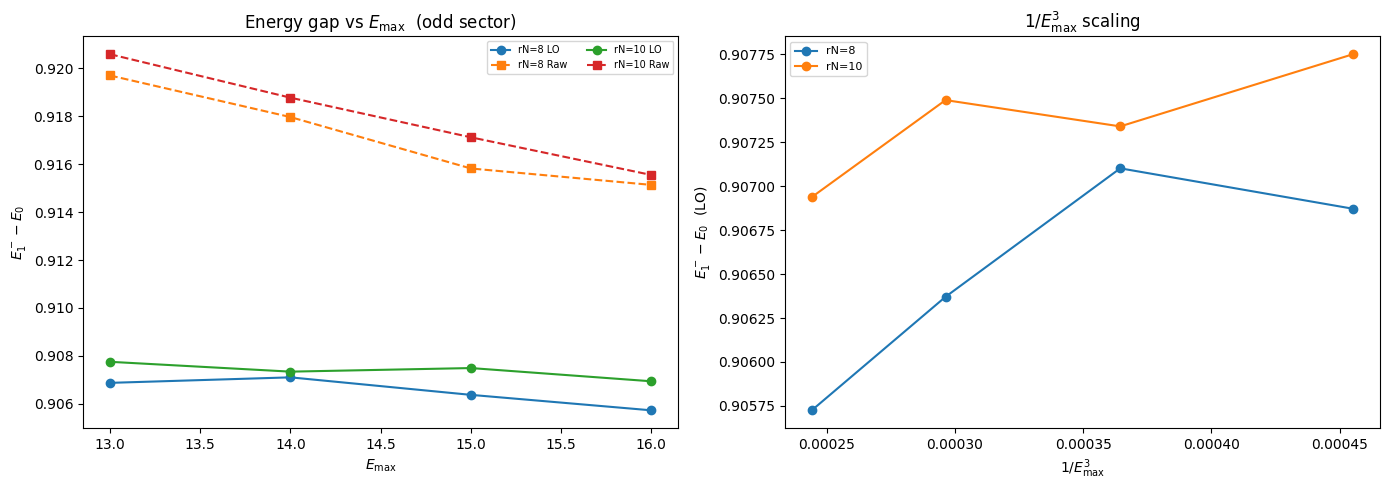

In [ ]:
# Energy gap E1--E0 vs E_max for each volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rN, results in all_results.items():
    emax_vals = [r['e_max'] for r in results]
    gap_LO    = [r['eigs_LO'][0]-r['E0_LO'][0]  for r in results if len(r['eigs_LO'])  > 1]
    gap_raw   = [r['eigs_raw'][0]-r['E0_raw'][0] for r in results if len(r['eigs_raw']) > 1]
    label = f'rN={rN}'
    axes[0].plot(emax_vals, gap_LO,  'o-',  label=f'{label} LO')
    axes[0].plot(emax_vals, gap_raw, 's--', label=f'{label} Raw')
    axes[1].plot([1/e**3 for e in emax_vals], gap_LO, 'o-', label=label)

axes[0].set_xlabel('$E_\\mathrm{max}$')
axes[0].set_ylabel('$E_1^- - E_0$')
axes[0].set_title('Energy gap vs $E_\\mathrm{max}$  (odd sector)')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('$1/E_\\mathrm{max}^3$')
axes[1].set_ylabel('$E_1^- - E_0$  (LO)')
axes[1].set_title('$1/E_\\mathrm{max}^3$ scaling')
axes[1].legend(fontsize=8)

fig.tight_layout()


# Almost agrees with eg https://arxiv.org/pdf/2507.15941 eg Figure 2, but that includes NLO correction which we don't have. 